In [3]:
# displays static in notebook
%matplotlib inline  
# displays interactive outside notebook
#%matplotlib   
# displays interactive in notebook
#%matplotlib notebook  

# to work correctly with numbers
import numpy as np

# plotting
import matplotlib.pyplot as plt
import matplotlib as mpl

# conversion between coordinate systems
import astropy.coordinates as coord
import astropy.units as u

#from astropy import units as u
from astropy.coordinates import SkyCoord

from scipy import stats
import scipy as scipy
from scipy.ndimage.interpolation import rotate
from scipy.interpolate import BSpline, make_interp_spline



# for making data catalogues that are easily uploaded to Javascript
import json

# for loading fits files
from astropy.io import fits



/var/folders/pv/tlm05vm94wj3nxs2mlbpt00c0000gp/T/ipykernel_10658/3493307354.py:24: DeprecationWarning: Please use `rotate` from the `scipy.ndimage` namespace, the `scipy.ndimage.interpolation` namespace is deprecated.
  from scipy.ndimage.interpolation import rotate


In [5]:

folder = ''

mpl.rcParams['font.family']='serif'
mpl.rcParams['font.size']=14

In [7]:
# Units

M_earth = 5.97E24
r_earth = 6.37E6
T_earth = 254.0
M_sun = 1.989E30
L_sun = 3.839E26
r_sun = 6.957e8
AU = 1.496E11
pc = 3.086E16
sigma = 5.67E-8
G = 6.67E-11
c = 2.997E8



# Pejcha 2012
Provides a physical model and algorithm for calculating broadband magnitudes for Cepheids with periods from 10 to 100 days

In [57]:
# equation 1
# mi(t) = Mi + mu + R1 E(B-V) - 5 log (R(t) / Ro) - 2.5 Beta1 log (T / T0)
# equation 4 & 5
# log (R/R0) = rho0 + A^2 deltaRho(phi)
# log (T/T0) = tau0 + A^2 deltaTau(phi)
# equation 20a
# rho0 = (0.777+/-0.002) + (0.698+/-0.006) log (Period / 10 days)
# equation 20b
# tau0 = (0.031+/-0.002) - (0.061+/-0.005) log (Period / 10 days)

# mi:  observed magnitude in band i
# Mi:  absolute magnitude of "mean" Cepheid in band i
# mu:  distance modulus
# R1:  ratio of total to selective extinction in band i
# E(B-V):  the reddening
# R(t), T(t): radius and temperature at time t

# Beta1 and R1 come from Table 3

R0 = 10 #rsun
T0 = 5400 #K

def rho0tau0(period):
    # uses equations 20a & b from Pejcha '12
    rho0 = 0.777 + 0.698 * np.log10(period / 10)
    tau0 = 0.031 - 0.061 * np.log10(period / 10)
    return rho0, tau0

def bandInfo(band, verbose=False):
    
    bands = ['U', 'B', 'V', 'R_C', 'I_C', \
             'J_SAAO', 'H_SAAO', 'K_SAAO', \
             'R_J', 'I_J', \
             'J_CTIO', 'H_CTIO', 'K_CTIO', \
             'C', 'M', 'T_1', 'T_2', \
             'Hp', 'B_T', 'V_T', \
             'V_W', 'B_W', 'U_W', 'W_W', 'L_W', \
             'IRAC 3.6 mum', 'IRAC 4.5 mum', 'IRAC 5.8 mum', 'IRAC 8.0 mum']
    if verbose:
        for i in np.arange(len(bands)):
            print(i, bands[i])

    Mi0s = [1.66, 1.0306, 0.1557, -0.2792, -0.6877, \
            -1.1488, -1.5679, -1.6356, \
            -0.4787, -0.9137, \
            -1.1898, -1.5571, -1.6435, \
            1.3852, 0.366, -0.2774, -0.6781, \
            0.3534, 1.739, 0.2065, \
            -6.6645, -5.764, -4.3928, -3.5206, -4.7697, \
            -1.7672, -1.7263, -1.7603, -1.7901]

    beta0s = [5.246, 4.303, 3.303, 2.623, 1.993, \
              0.784, 0.422, 0.2, \
              2.308, 1.478, \
              0.724, 0.426, 0.255, \
              4.725, 3.633, 2.682, 1.934, \
              3.154, 3.523, 3.52, \
              3.417, 4.515, 5.254, 5.753, 4.887, \
              0.171, 0.129, 0.086, 0.052]
    
    if verbose:
        print('Loading information for band: ', band, bands[band])
        print('Mi, beta_i: ', Mi0s[band], beta0s[band])

    return Mi0s[band], beta0s[band]
    

def Cepheid_lightcurve(period, times, band, verbose=False, extra_outputs = False):

    # calculate phase for each time
    phi = times / period
    if verbose:
        print('number of times, phis: ', len(times), len(phi))

    # load coefficients to use with Pejcha eq. 7 & 8
    dataFile='Pejcha_2012_ApJ_748_107_table4.txt'
    logP10, coeff, Ctau, Stau, Crho, Srho = np.loadtxt(dataFile, unpack = True, skiprows=23)
    #if verbose:
    #    for i in np.arange(len(logP10)):
    #        print(logP10[i], coeff[i], Ctau[i], Stau[i], Crho[i], Srho[i])

    # TEMPORARY.  NEED TO REPLACE WITH INTERPOLATION OF COEFFS, LINEAR IN LOG(P/10)
    # select closest log P from list
    useLogP = np.unique(logP10)[np.argmin(np.abs(np.log10(period/10) - np.unique(logP10)))]
    #useLogP = 0.0
 
    useCoeffs = logP10 == useLogP
    if verbose:
        print('use logP = ', useLogP)
        print(useCoeffs)

    Crho_use = Crho[useCoeffs]
    Srho_use = Srho[useCoeffs]
    Ctau_use = Ctau[useCoeffs]
    Stau_use = Stau[useCoeffs]
    if verbose:
        print('Crho_use:  ',Crho_use)
   
    dRho = 0.0
    dTau = 0.0
    if verbose:
        print('j, Crho_use[j], Srho_use[j], Ctau_use[j], Stau_use[j]')
    for j in np.arange(np.sum(useCoeffs)):
#    for j in [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]:
        if verbose:
           print(j, Crho_use[j], Srho_use[j], Ctau_use[j], Stau_use[j])
        # Pejcha iterated counting 1, 2, 3... 20 ; Python arrays iterate 0, 1, 2... 19
        # hence need to add 1 within the cosine and sine functions
        dRho += Crho_use[j] * np.cos(2*np.pi*(j+1)*phi) + Srho_use[j]*np.sin(2*np.pi*(j+1)*phi)
        dTau += Ctau_use[j] * np.cos(2*np.pi*(j+1)*phi) + Stau_use[j]*np.sin(2*np.pi*(j+1)*phi)
        
    if verbose:
        print('number of dRho, dTau: ', len(dRho), len(dTau))
        print('dRho ranges from ', np.min(dRho), ' to ', np.max(dRho))
        print('dTau ranges from ', np.min(dTau), ' to ', np.max(dTau))

    # lookup absolute magnitude and beta based on desired band for model
    MiBar, betaV0 = bandInfo(band, verbose=False)   
    
    # calculate deviation from "mean Cepheid" of 10 Rsun and 5400 K
    rho0, tau0 = rho0tau0(period)
    
    # calculate mean magnitude
    M0 = MiBar - 5 * rho0 - 2.5 * betaV0 * tau0
    if verbose:
        print('Mi, beta, rho0, tau0, M0: ', MiBar, betaV0, rho0, tau0, M0)


    # Pejcha 2012 equation 1, 4, & 5
    A2 = A2_Pejcha(period)
    lightcurve = M0 + -5 * A2 * dRho - 2.5 * betaV0 * A2 * dTau
    if verbose:
        print('A2: ', A2)
        print('lightcurve ranges from ', np.max(lightcurve), ' to ', np.min(lightcurve))

    if extra_outputs:
        return lightcurve, phi, dRho, dTau
    else:    
        return lightcurve, phi

def A2_Pejcha(period):
    if (np.log10(period/10) < 0.24):
        A2 = (13.5 * np.log10(period/10) + 2.75) / 100
    else:
        A2 = 0.06
    return A2
    
def Cepheid_size_calc(rho0, A2, dRho, verbose=False, extra_outputs = False):
    # log (R/R0) = rho0 + A^2 deltaRho(phi)    # equation 4
    R0 = 10 # rsun
    sizes = R0 * 10**(rho0 + A2 * dRho)
    return sizes

def Cepheid_temp_calc(tau0, A2, dTau, verbose=False, extra_outputs = False):
    # log (T/T0) = tau0 + A^2 deltaTau(phi)    # equation 5
    T0 = 5400 # K
    temperatures = T0 * 10**(tau0 + A2 * dTau)
    return temperatures



rho0, tau0:  0.777 0.031
Loading information for band:  2 V
Mi, beta_i:  0.1557 3.303
MiBar, betaV0:  0.1557 3.303
mean absolute V mag:  -3.9852825000000003
use logP =  0.0
Loading information for band:  2 V
Mi, beta_i:  0.1557 3.303
-3.7805329167030024 -4.16756257925304


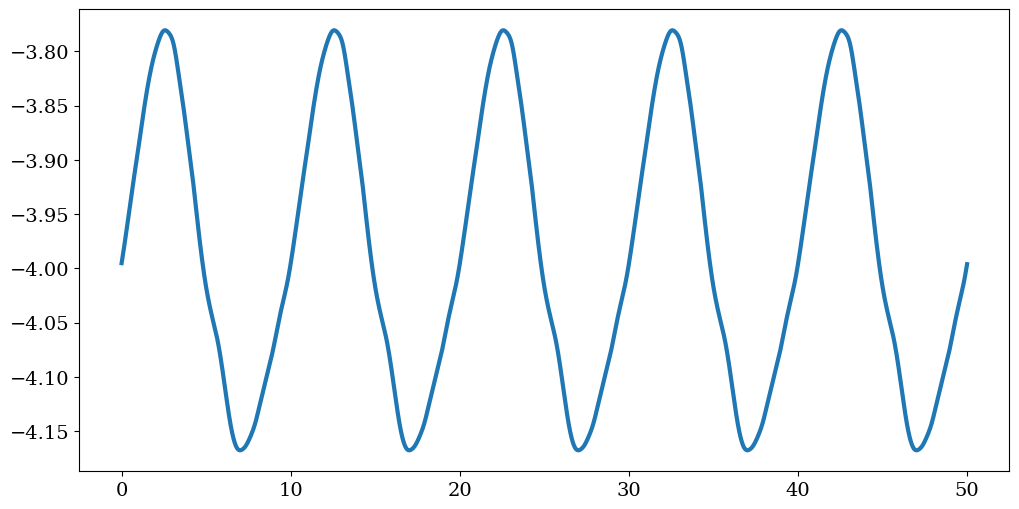

In [27]:
period = 10

rho0, tau0 = rho0tau0(period)
print('rho0, tau0: ', rho0, tau0)

MiBar, betaV0 = bandInfo(2, verbose=False)
print('MiBar, betaV0: ', MiBar, betaV0)

Mv0 = MiBar - 5 * rho0 - 2.5 * betaV0 * tau0
print('mean absolute V mag: ', Mv0)

times = np.arange(0, 50, 0.01)
Mv, phi, dRho, dTau = Cepheid_lightcurve(period, times, 2, verbose=False, extra_outputs = True)

print(np.max(Mv), np.min(Mv))


fig = plt.figure(figsize=(12,6))
plt.plot(times, Mv, linewidth=3)
#plt.plot(times, Mv, linewidth=3)
#plt.xlim(0,1.1)
#plt.ylim(5, np.min(Mv)-0.2)
#plt.ylim(-2, -5)

# draw a line at sun's Vmag
#plt.plot([0,100], [4.8, 4.8], linewidth=3)



In [29]:
for i in np.arange(len(times)):
    print(2.5**(4.8 - Mv[i]))

3161.771607571046
3158.9519500536794
3156.1151425704857
3153.2621734213535
3150.394006909549
3147.511574142241
3144.6157645558706
3141.707418285425
3138.7873194852036
3135.8561906950913
3132.9146883315952
3129.9633993665975
3127.002839239567
3124.0334510308026
3121.0556059047244
3118.069604813176
3115.0756814298643
3112.0740062683712
3109.0646919180645
3106.0477993151
3103.0233449494312
3099.991308894101
3096.9516435298447
3093.9042828265947
3090.8491520342486
3087.786177627658
3084.715297345867
3081.636470163049
3078.5496860284184
3075.4549752145663
3072.352417118515
3069.2421483666662
3066.124370084423
3062.999354202527
3059.8674486859404
3056.7290815861975
3053.5847638352666
3050.435090717065
3047.28074197219
3044.122480511457
3040.9611497344526
3037.797669469937
3034.6330305756774
3031.468288255162
3028.3045541682927
3025.1429874311484
3021.9847846170633
3018.831168886651
3015.683378387756
3012.542654078241
3009.4102271335178
3006.287306108065
3003.1750640247947
3000.074625568167
2

use logP =  0.0
Loading information for band:  2 V
Mi, beta_i:  0.1557 3.303
use logP =  0.3
Loading information for band:  2 V
Mi, beta_i:  0.1557 3.303
use logP =  0.8
Loading information for band:  2 V
Mi, beta_i:  0.1557 3.303


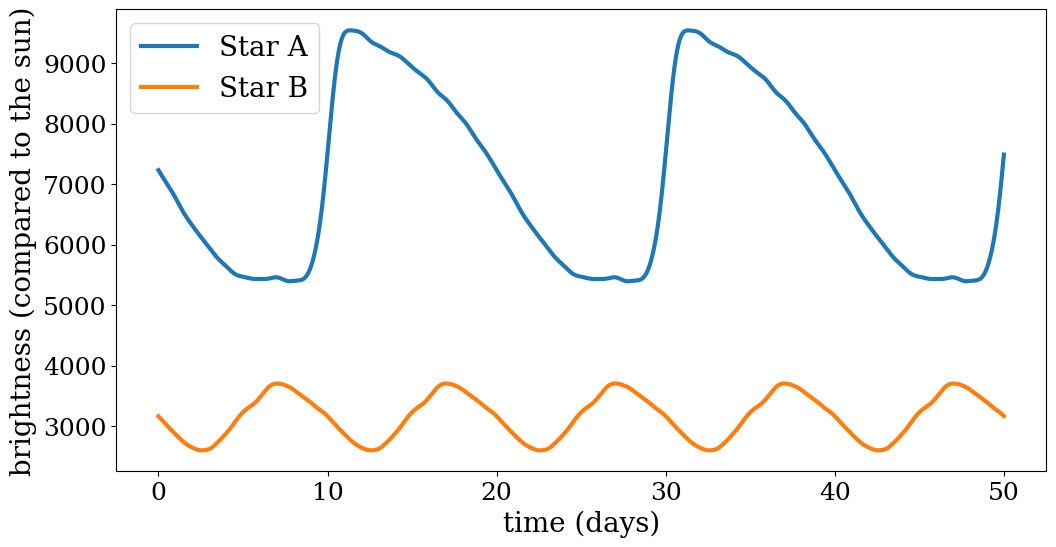

In [31]:
P1 = 10
P2 = 20
P3 = 60


times = np.arange(0, 50, 0.01)
Mv1, phi1 = Cepheid_lightcurve(P1, times, 2, verbose=False)
Mv2, phi2 = Cepheid_lightcurve(P2, times, 2, verbose=False)
Mv3, phi3 = Cepheid_lightcurve(P3, times, 2, verbose=False)


fig = plt.figure(figsize=(12,6))
#plt.plot(times, 2.5**(4.8-Mv3), linewidth=3, label='Star A')
plt.plot(times, 2.5**(4.8-Mv2), linewidth=3, label='Star A')
plt.plot(times, 2.5**(4.8-Mv1), linewidth=3, label='Star B')

plt.xlabel('time (days)', fontsize=20)
plt.ylabel('brightness (compared to the sun)', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

legend = plt.legend(loc='upper left', shadow=False, fontsize=20)

#plt.savefig('Cepheid_lightcurve_comparison_10_25_days.jpg')



In [17]:
#############
##
##  Output table 4 from Pejcha in format for easy loading in JS
##

dataFile='Pejcha_2012_ApJ_748_107_table4.txt'
logP10, coeff, Ctau, Stau, Crho, Srho = np.loadtxt(dataFile, unpack = True, skiprows=23)

for i in np.arange(len(logP10)):
    print('[',logP10[i], ', ', coeff[i], ', ', Ctau[i], ', ', Stau[i], ', ', Crho[i], ', ', Srho[i], '],')
    


[ 0.0 ,  1.0 ,  -0.655942 ,  -0.799722 ,  1.0 ,  0.0 ],
[ 0.0 ,  2.0 ,  0.0432002 ,  -0.009407 ,  0.0424302 ,  0.0816138 ],
[ 0.0 ,  3.0 ,  0.0166285 ,  0.0658372 ,  -0.0105897 ,  -0.039046 ],
[ 0.0 ,  4.0 ,  0.00395908 ,  -0.0288813 ,  0.0082202 ,  0.0118774 ],
[ 0.0 ,  5.0 ,  -0.00588958 ,  0.0080528 ,  -0.000352807 ,  -0.000958669 ],
[ 0.0 ,  6.0 ,  0.00735751 ,  0.00151437 ,  0.00511735 ,  -0.00142921 ],
[ 0.0 ,  7.0 ,  -0.00615025 ,  -0.00394491 ,  -1.72599e-06 ,  0.00270471 ],
[ 0.0 ,  8.0 ,  0.00418875 ,  0.00347581 ,  0.000957207 ,  -0.00494847 ],
[ 0.0 ,  9.0 ,  0.000190958 ,  2.546e-05 ,  0.00328564 ,  -3.39728e-05 ],
[ 0.0 ,  10.0 ,  0.000704976 ,  0.000614612 ,  0.000373839 ,  -0.00345807 ],
[ 0.0 ,  11.0 ,  -0.000463388 ,  -0.000341031 ,  0.00287978 ,  -0.000331189 ],
[ 0.0 ,  12.0 ,  -0.000286117 ,  0.000178882 ,  -0.000168316 ,  0.000228903 ],
[ 0.0 ,  13.0 ,  -0.00019086 ,  -0.000288726 ,  -0.000493956 ,  0.000255491 ],
[ 0.0 ,  14.0 ,  -0.000113362 ,  -3.14758e-05 ,  -

[ 0.5 ,  8.0 ,  0.00526843 ,  0.00160812 ,  -0.00257648 ,  -0.00345094 ],
[ 0.5 ,  9.0 ,  -0.00334049 ,  -0.00314613 ,  0.00433753 ,  0.00287736 ],
[ 0.5 ,  10.0 ,  0.00309703 ,  0.000848094 ,  -0.00141944 ,  0.00138427 ],
[ 0.5 ,  11.0 ,  0.000353728 ,  -0.00107642 ,  -0.000433502 ,  -0.000892068 ],
[ 0.5 ,  12.0 ,  0.000776745 ,  0.0015157 ,  0.00113003 ,  -0.000608972 ],
[ 0.5 ,  13.0 ,  -0.00158538 ,  -0.000612182 ,  0.000343963 ,  0.000780758 ],
[ 0.5 ,  14.0 ,  0.000155931 ,  0.000910535 ,  0.00087779 ,  -0.000140814 ],
[ 0.5 ,  15.0 ,  -0.000506751 ,  -5.88008e-05 ,  0.00149877 ,  -8.96012e-05 ],
[ 0.5 ,  16.0 ,  0.000309279 ,  -0.000284863 ,  -0.00101151 ,  0.00013274 ],
[ 0.5 ,  17.0 ,  -0.000602786 ,  -0.000196809 ,  -0.000794928 ,  0.000940836 ],
[ 0.5 ,  18.0 ,  -0.000172729 ,  -0.000359029 ,  -0.000152053 ,  0.00139958 ],
[ 0.5 ,  19.0 ,  -0.00032503 ,  1.33608e-06 ,  0.000256658 ,  -0.000558125 ],
[ 0.5 ,  20.0 ,  -0.000141313 ,  2.21312e-05 ,  0.00157811 ,  0.000483038 ]

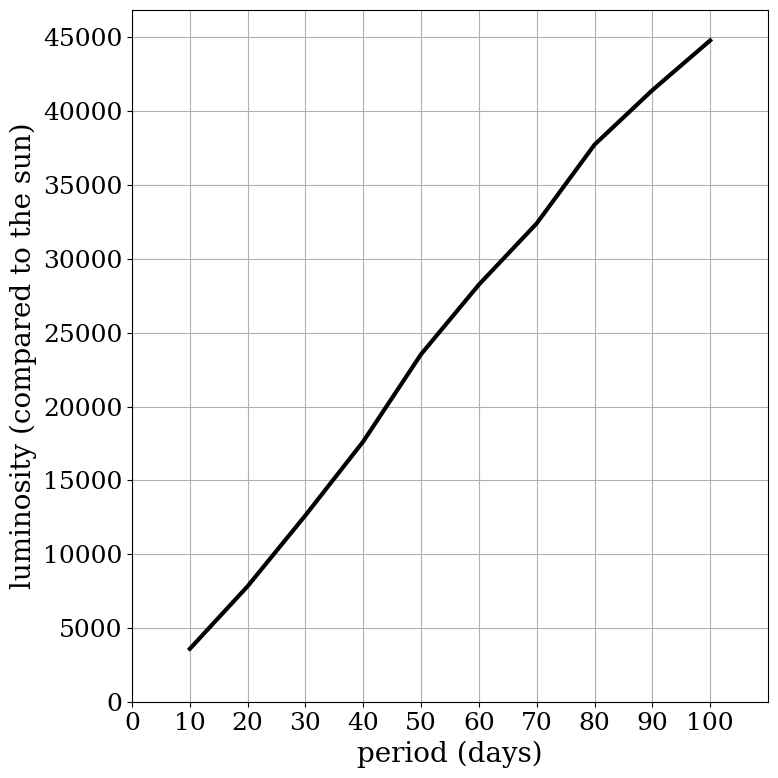

In [81]:
# generate a PL graph using the Pejcha model

periods = range(10,101, 10)
lums = np.array([])
for i in periods:
    period = i
    #print('period: ', i, ' days')
    rho0, tau0 = rho0tau0(period)
    #print('  rho0, tau0: ', rho0, tau0)
    MiBar, betaV0 = bandInfo(2, verbose=False)
    #print('  MiBar, betaV0: ', MiBar, betaV0)
    Mv0 = MiBar - 5 * rho0 - 2.5 * betaV0 * tau0
    #print('  mean absolute V mag: ', Mv0)
    times = np.arange(0, 50, 0.01)
    Mv, phi, dRho, dTau = Cepheid_lightcurve(period, times, 2, verbose=False, extra_outputs = True)
    #print('  nElements dRho, dTau: ', len(dRho), len(dTau))
    #print('  mean dRho, dTau: ', np.mean(dRho), np.mean(dTau))
    A2 = A2_Pejcha(period)
    #print('  A^2: ', A2)
    sizes = Cepheid_size_calc(rho0, A2, dRho)
    temperatures = Cepheid_temp_calc(tau0, A2, dTau)
    #print('  mean size, temp: ', np.mean(sizes), np.mean(temperatures))
    luminosities = sizes**2 * (temperatures / 5800)**4
    #print('  mean luminosity: ', np.mean(luminosities))
    lums = np.append(lums, np.mean(luminosities))


fig = plt.figure(figsize=(8,8))
plt.plot(periods, lums, linewidth=3, c='black')

plt.xlabel('period (days)', fontsize=20)
plt.ylabel('luminosity (compared to the sun)', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlim(0,110)
plt.xticks(np.arange(0, 101, 10.0))
plt.yticks(np.arange(0, 50000, 5000.0))
plt.grid(True)


#legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
fig.tight_layout()

plt.savefig('Cepheid_period_luminosity_relation.jpg')




[ 5340.80871604 12799.96328315 21344.02130197 30679.07373499
 40650.2929517  51159.73596339 62139.0093345  73537.25268391
 85314.94887666 97440.38325224]
[1.47606098 1.62999502 1.68783011 1.73898112 1.72704257 1.81143352
 1.918912   1.95036063 2.06141636 2.17739674]


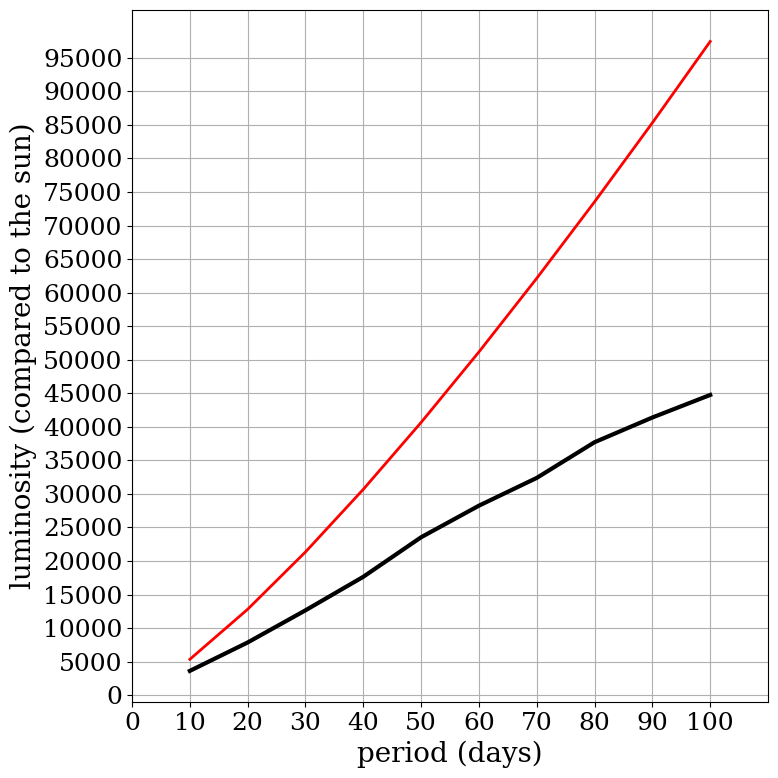

In [97]:
# compare with graph based on Saio & Gautschy 1999

# 
# blue edge: log L/Lsun = 2.573 + 1.270 log P
# red edge:  log L/Lsun = 2.326 + 1.244 log P

SG99b = 10**(2.573 + 1.270 * np.log10(periods))
SG99r = 10**(2.326 + 1.244 * np.log10(periods))
SG99 = np.mean([SG99b, SG99r], axis=0)
print(SG99)


fig = plt.figure(figsize=(8,8))
plt.plot(periods, lums, linewidth=3, c='black')
plt.plot(periods, SG99, linewidth=2, linestyle='-', c='red')
#plt.plot(np.log10(periods), np.log10(lums), linewidth=3, c='black')
#plt.plot(np.log10(periods), np.log10(SG99), linewidth=2, linestyle='-', c='red')

plt.xlabel('period (days)', fontsize=20)
plt.ylabel('luminosity (compared to the sun)', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlim(0,110)
plt.xticks(np.arange(0, 101, 10.0))
plt.yticks(np.arange(0, 100000, 5000.0))
plt.grid(True)

print(SG99 / lums)

#legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
fig.tight_layout()
#plt.savefig('Cepheid_period_luminosity_relation.jpg')


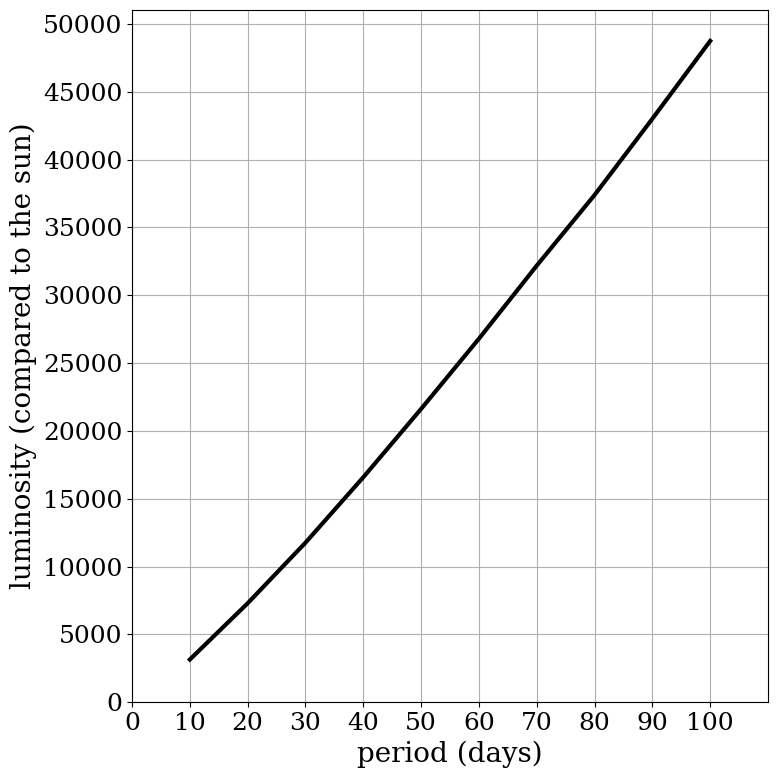

In [121]:
# generate V band PL relation graph, for easier comparison to astrosim

periods = range(10,101, 10)
lums = np.array([])
for i in periods:
    period = i
    #print('period: ', i, ' days')
    rho0, tau0 = rho0tau0(period)
    #print('  rho0, tau0: ', rho0, tau0)
    MiBar, betaV0 = bandInfo(2, verbose=False)
    #print('  MiBar, betaV0: ', MiBar, betaV0)
    Mv0 = MiBar - 5 * rho0 - 2.5 * betaV0 * tau0
    #print('  mean absolute V mag: ', Mv0)
    times = np.arange(0, period, 0.01)
    Mv, phi, dRho, dTau = Cepheid_lightcurve(period, times, 2, verbose=False, extra_outputs = True)
    #print('  nElements dRho, dTau: ', len(dRho), len(dTau))
    #print('  mean dRho, dTau: ', np.mean(dRho), np.mean(dTau))
    A2 = A2_Pejcha(period)
    #print('  A^2: ', A2)
    sizes = Cepheid_size_calc(rho0, A2, dRho)
    temperatures = Cepheid_temp_calc(tau0, A2, dTau)
    #print('  mean size, temp: ', np.mean(sizes), np.mean(temperatures))
    luminosities = sizes**2 * (temperatures / 5800)**4
    #print('  mean luminosity: ', np.mean(luminosities))
    lums = np.append(lums, np.mean(2.5**(4.8-Mv)))


fig = plt.figure(figsize=(8,8))
plt.plot(periods, lums, linewidth=3, c='black')

plt.xlabel('period (days)', fontsize=20)
#plt.ylabel('brightness (V filter, compared to the sun)', fontsize=20)
plt.ylabel('luminosity (compared to the sun)', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlim(0,110)
plt.xticks(np.arange(0, 101, 10.0))
plt.yticks(np.arange(0, 50001, 5000.0))
plt.grid(True)
#plt.annotate('based on Pejcha & Kochanek 2012, APJ 748, 107', xy = (50, 150), fontsize=10, c='gray')

#legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
fig.tight_layout()

plt.savefig('Cepheid_period_Vband_relation_noCite_simplifiedLabel.jpg')



## Early experiments 

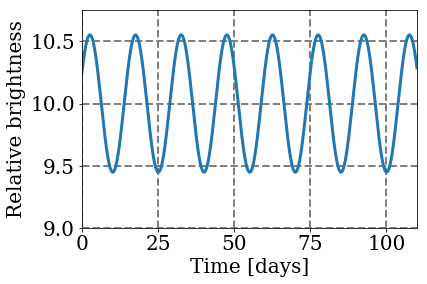

In [36]:
###################
##
##  Cepheid fake light curve

period = 15.0
amplitude = 0.5
baseline = 10.0

t = np.arange(0,200,0.1)

#period = 9.0
#time = t - np.cos(2*np.pi / period * t)
#brightness = amplitude * np.cos(2*np.pi / period * t) + baseline

time = t
brightness = 0.495 * np.sin(2*np.pi / period * t) + 0.245 * np.cos(2*np.pi / period * t) + baseline

#brightness = baseline + amplitude * (np.sin(2*np.pi / period * time) * np.mod(time+2, period) / period)
#brightness = baseline + amplitude - amplitude * np.mod(time, period) / period

fig = plt.figure()
plt.plot(time,brightness, linewidth=3)
plt.ylim(9,10.75)
plt.xlim(0,110)

plt.xlabel(r'Time [days]', fontsize=20)
plt.ylabel(r'Relative brightness', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)

ax = fig.gca()
ax.grid(True)
ax.grid(linestyle='dashed', linewidth=2,color='gray')


(0.7, -0.7)

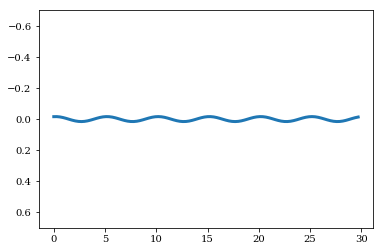

In [29]:
## code to reconstruct light curve function from Inno+ '15
## INNO 2015 REMOVED AMPLITUDE DATA

period_bins_Inno_J = np.array([1, 3, 5, 7, 9.5, 10.5, 13.5, 15.5, 20, 30])

A7_J = np.array([
    [-0.002, 0.325, 0.174, 0.107, 0.076, 0.046, 0.032, 0.022],
    [-0.001, 0.373, 0.172, 0.092, 0.051, 0.032, 0.017, 0.012],
    [0.003, 0.418, 0.156, 0.077, 0.028, 0.014, 0.003, 0.007],
    [0.004, 0.430, 0.134, 0.083, 0.016, 0.012, 0.012, 0.005],
    [-0.018, 0.424, 0.040, 0.002, 0.028, 0.019, 0.004, 0.015],
    [0.000, 0.412, 0.076, 0.028, 0.021, 0.011, 0.011, 0.005],
    [-0.002, 0.486, 0.093, 0.063, 0.063, 0.045, 0.045, 0.024],
    [-0.002, 0.477, 0.106, 0.067, 0.060, 0.046, 0.017, 0.015],
    [-0.003, 0.424, 0.114, 0.067, 0.039, 0.030, 0.012, 0.012],
    [-0.004, 0.413, 0.133, 0.067, 0.047, 0.033, 0.016, 0.015]    
])

phi7_J = np.array([
    [0, 1.583, 1.610, 1.648, 1.633, 1.543, 1.412, 0.995],
    [0, 1.460, 1.652, 1.702, 1.728, 1.814, 1.657, 1.661],
    [0, 1.423, 1.823, 1.903, 1.843, 1.310, 0.951, 1.921],
    [0, 1.355, 2.011, 2.114, 1.261, 2.292, 1.135, 1.849],
    [0, 1.494, -3.112, 0.199, 0.404, 2.548, 0.643, 1.396],
    [0, 1.616, 2.225, 0.787, 0.811, 0.952, -0.018, 1.117],
    [0, 1.421, 2.070, 1.581, 1.535, 1.591, 1.910, 2.081],
    [0, 1.416, 2.026, 1.623, 1.550, 1.776, 2.188, 2.045],
    [0, 1.218, 1.731, 2.331, 2.652, -3.129, -2.609, -2.159],
    [0, 1.215, 1.802, 2.115, 2.409, 2.390, 2.912, -2.382]    
])


phases = np.arange(0,1,0.01)
binNum = 9

Jmag = np.zeros(len(phases))
#for i in np.arange(len(A7_J[binNum])):
#for i in np.arange(7):
for i in [6]:
    Jmag += A7_J[binNum][i] * np.cos(2*np.pi*i*phases + phi7_J[binNum][i])

    
    
fig = plt.figure()
plt.plot(phases * period_bins_Inno_J[binNum], Jmag, linewidth=3)
plt.ylim(0.7, -0.7)
#plt.xlim(0,110)


In [ ]:
# Ragosta+ '19
# period-radius
# period-luminosity for V, I, Ks bands

period = np.arange(0.3, 60)
radius = 10**(0.7 * np.log10(period) + 1.12)
Vmag = -2.63 * np.log10(period) - 1.54
Imag = -2.93 * np.log10(period) - 1.95
Kmag = -3.30 * np.log10(period) - 2.43


In [ ]:
# Tamman 2012

if (period <= 10):
    Vmag = -2.86 * np.log10(period) - 1.46
else:
    Vmag = -2.48 * np.log10(period) - 1.81



In [ ]:
# maximum amplitude from Schaltenbrand and Tammann
# referenced in Sandage & Tammann 1971

deltaMag = -0.392 * np.log10(period) + 1.736

use logP =  0.0
[ 1.00000e+00  4.24302e-02 -1.05897e-02  8.22020e-03 -3.52807e-04
  5.11735e-03 -1.72599e-06  9.57207e-04  3.28564e-03  3.73839e-04
  2.87978e-03 -1.68316e-04 -4.93956e-04 -3.89795e-04  1.17149e-03
 -1.20511e-03 -4.83337e-04  9.65609e-04 -6.62260e-05  5.10411e-04]
dRho ranges from  -1.0005185634297806  to  1.0519706510079845
dTau ranges from  -1.0541697050779348  to  1.0541403796534001


(0.0, 1.0)

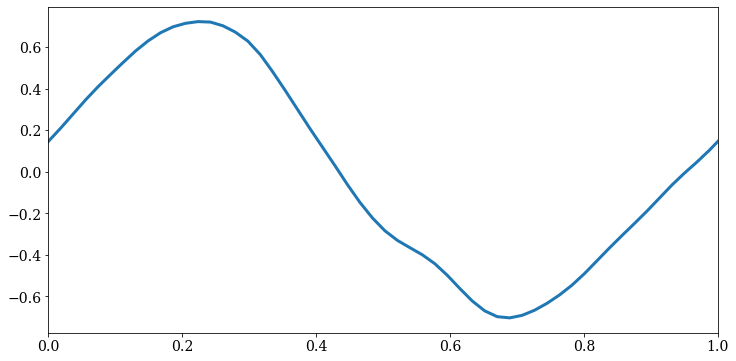

In [163]:
# Pejcha 2012
# for periods from 10 to 100 days

time = np.arange(0,100, 0.1)
period = 5.37

Vmag = -2.703 * np.log10(period / 10) - 4.130


# from table 3
Vmag0 = 0.1557
Vbeta = 5.1404
Vextinction = 3.303

# from section 1.2
R0 = 10
T0 = 5400

# load table 4
# calculate R and T vs. phase
dataFile='Pejcha_2012_ApJ_748_107_table4.txt'
logP10, coeff, Ctau, Stau, Crho, Srho = np.loadtxt(dataFile, unpack = True, skiprows=23)
#print(np.unique(logP10))


# equation 4 & 5
#a = np.log10(mean_radius/R0)
#b = np.log10(mean_temperature / T0)

# equation 11
#Vmag = Vmag0 - 5 * a - 2.5 * Vbeta * 

# use log period to interpolate values for Crho,J, Srho,J, Ctau,J, and Stau,J from table 4
#l, r = [(1, 0.0)], [(1, 0.0)]
#b_n = make_interp_spline(wavelength, RV3p1, bc_type=(l, r))

# TEMPORARY
# select closest log P from list
#print(np.abs(np.log10(period/10) - np.unique(logP10)))
useLogP = np.unique(logP10)[np.argmin(np.abs(np.log10(period/10) - np.unique(logP10)))]
print('use logP = ', useLogP)
useCoeffs = logP10 == useLogP
#print(useCoeffs)

Crho_use = Crho[useCoeffs]
Srho_use = Srho[useCoeffs]
Ctau_use = Ctau[useCoeffs]
Stau_use = Stau[useCoeffs]
print(Crho_use)

phi = time / period
#print(phi)
phaseShift = -0.5

dRho = 0.0
dTau = 0.0
for j in np.arange(1,20,1):
    dRho += Crho_use[j-1] * np.cos(2*np.pi*j*phi) + Srho_use[j-1]*np.sin(2*np.pi*j*phi)
    dTau += Ctau_use[j-1] * np.cos(2*np.pi*j*phi) + Stau_use[j-1]*np.sin(2*np.pi*j*phi)
    
print('dRho ranges from ', np.min(dRho), ' to ', np.max(dRho))
print('dTau ranges from ', np.min(dTau), ' to ', np.max(dTau))

dVmag = -5*dRho - 2.5 * Vbeta * dTau
deltaMag = -0.392 * np.log10(period) + 1.736

# compare shapes of dRho and dTau with fig. 5
# compare shape of dVmag with fig. 2
fig = plt.figure(figsize=(12,6))
#plt.plot(phi, dRho, linewidth=3)
#plt.plot(phi, dTau, linewidth=3)
plt.plot(phi, deltaMag / 2 * dVmag / np.max(dVmag), linewidth=3)
#plt.ylim(1.1*np.max(dRho), 1.1*np.min(dRho))
plt.xlim(0,1.0)



In [ ]:
# Turner '12
L = 10**(1.168 * np.log10(period) + 2.409)

In [ ]:
# apply variability range to the magnitudes of the lightcurve

In [ ]:
# use period-luminosity relationship to set mean magnitude (so, offset function)

period, log10:  13.513 1.130751776765143
number of sin/cos terms 16
gammas for P=10 days are about:  -0.19 -0.09 0.01 -0.02
[-0.05540708  0.05667615 -0.01898145  0.00431179]
-0.055407078414994315
   1 0.523 0.335
   2 0.0 0.125
   3 -0.039 -0.059
   4 0.469 0.275
   5 -0.347 -0.22
   6 -0.077 -0.059
   7 0.108 0.071
   8 -0.216 -0.13
   9 0.098 0.057
   10 0.103 0.063
   11 -0.076 -0.048
   12 0.034 0.018
   13 0.005 0.005
   14 -0.042 -0.025
   15 0.004 0.003
   16 0.0 0.002
0.05667615480202251
   1 0.376 0.233
   2 0.0 -0.019
   3 -0.141 -0.048
   4 -0.127 -0.091
   5 0.271 0.211
   6 -0.319 -0.183
   7 0.266 0.162
   8 0.328 0.221
   9 -0.316 -0.198
   10 0.123 0.074
   11 -0.024 -0.025
   12 -0.22 -0.144
   13 0.111 0.074
   14 0.026 0.01
   15 -0.03 -0.022
   16 0.017 0.014
-0.01898145432812667
   1 -0.383 -0.308
   2 0.0 0.012
   3 -0.134 -0.089
   4 -0.081 -0.057
   5 -0.255 -0.141
   6 -0.295 -0.202
   7 0.389 0.225
   8 -0.179 -0.119
   9 0.015 0.001
   10 0.33 0.192
   11 -0.

(0.0, 28.3773)

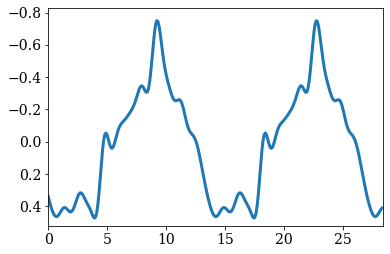

In [93]:
# Tanvir+ '05
# TANVIR 2005 has errors in PCA tables


# Table A1
alpha_avg = np.array([0.395, 0.000, -0.018, 0.101, -0.022, -0.037, 0.030, -0.002, -0.004, 0.018, -0.009, -0.004, 0.004, -0.005, 0.000, 0.000])
beta_avg = np.array([0.245, 0.064, -0.015, 0.057, -0.011, -0.023, 0.019, 0.001, -0.004, 0.012, -0.007, -0.004, 0.003, -0.004, 0.001, 0.001])

alpha_PCA = np.array([
    [0.523, 0.000, -0.039, 0.469, -0.347, -0.077, 0.108, -0.216, 0.098, 0.103, -0.076, 0.034, 0.005, -0.042, 0.004, 0.000],
    [0.376, 0.000, -0.141, -0.127, 0.271, -0.319, 0.266, 0.328, -0.316, 0.123, -0.024, -0.220, 0.111, 0.026, -0.030, 0.017],
    [-0.383, 0.000, -0.134, -0.081, -0.255, -0.295, 0.389, -0.179, 0.015, 0.330, -0.233, -0.076, 0.062, -0.117, 0.010, 0.028],
    [-0.256, 0.000, 0.138, 0.409, -0.224, 0.021, 0.082, 0.150, -0.333, -0.051, 0.278, -0.276, 0.055, 0.260, -0.109, -0.043],
    [-0.071, 0.000, -0.658, 0.036, -0.075, -0.300, -0.148, 0.068, 0.004, -0.251, 0.148, 0.159, -0.167, 0.067, -0.047, -0.098],
    [-0.065, 0.000, -0.397, 0.033, 0.131, 0.393, -0.178, -0.127, -0.074, 0.200, -0.173, -0.322, 0.308, -0.103, -0.103, 0.071],
    [-0.074, 0.000, 0.079, -0.320, -0.235, -0.098, -0.008, -0.267, -0.066, -0.062, 0.301, -0.105, 0.058, 0.212, -0.125, -0.035],
    [0.149, 0.000, -0.037, -0.236, -0.173, 0.155, -0.006, -0.108, -0.016, 0.156, -0.074, -0.039, -0.144, 0.035, -0.254, -0.552],
    [-0.331, 0.000, 0.142, 0.185, 0.186, -0.122, -0.103, 0.215, -0.100, -0.005, -0.048, 0.012, 0.014, -0.320, 0.060, -0.453],
    [-0.037, 0.000, 0.147, 0.110, 0.190, -0.253, -0.096, -0.030, 0.357, -0.103, -0.129, 0.030, 0.397, 0.011, -0.441, -0.012 ]
])
    
beta_PCA = np.array([
    [0.335, 0.125, -0.059, 0.275, -0.220, -0.059, 0.071, -0.130, 0.057, 0.063, -0.048, 0.018, 0.005, -0.025, 0.003, 0.002],
    [0.233, -0.019, -0.048, -0.091, 0.211, -0.183, 0.162, 0.221, -0.198, 0.074, -0.025, -0.144, 0.074, 0.010, -0.022, 0.014],
    [-0.308, 0.012, -0.089, -0.057, -0.141, -0.202, 0.225, -0.119, 0.001, 0.192, -0.165, -0.051, 0.041, -0.075, -0.002, 0.015],
    [-0.198, 0.057, 0.047, 0.227, -0.117, 0.022, 0.022, 0.113, -0.238, -0.096, 0.202, -0.174, 0.036, 0.204, -0.114, -0.037],
    [-0.041, -0.144, -0.367, 0.067, -0.046, -0.183, -0.075, 0.004, 0.037, -0.169, 0.110, 0.117, -0.117, 0.064, -0.051, -0.080],
    [0.097, -0.216, -0.239, 0.125, -0.020, 0.235, -0.154, -0.122, -0.058, 0.055, -0.047, -0.220, 0.175, -0.021, -0.089, 0.017],
    [0.429, -0.479, 0.214, -0.166, -0.164, -0.087, 0.068, -0.181, 0.024, 0.043, 0.076, -0.077, 0.042, -0.007, -0.011, -0.025],
    [-0.029, 0.326, -0.062, -0.232, 0.024, 0.070, -0.052, 0.013, -0.099, 0.011, 0.046, -0.069, -0.057, 0.118, -0.224, -0.419],
    [0.301, -0.134, 0.066, 0.269, -0.062, -0.070, -0.021, -0.042, -0.015, 0.116, -0.142, 0.101, -0.008, -0.260, 0.079, -0.303],
    [-0.030, 0.013, 0.056, 0.001, -0.027, -0.187, 0.022, 0.127, 0.217, -0.164, 0.042, -0.012, 0.271, 0.096, -0.363, -0.026]
])
    
# Table A2
lambdas_by_gammas = np.array([
    [0.124, 0.313, -1.201, -0.281, -4.546, -2.476, 17.944],
    [-0.035, -0.557, 0.717, 3.530, -8.867, -0.906, 10.359], 
    [0.028, -0.232, -1.439, 3.233, 7.009, -14.092, 3.154],
    [-0.013, 0.034, 0.986, 0.745, -7.507, -2.470, 14.399]
])


period = 13.513
print('period, log10: ', period, np.log10(period))
times = np.arange(0,100,0.1)


Vmag = np.zeros(len(times))
print('number of sin/cos terms',len(alpha_avg))
for i in np.arange(16):
    Vmag += alpha_avg[i] * np.sin(2*np.pi*(i+1)*times / period) + beta_avg[i] * np.cos(2*np.pi*(i+1)*times / period)

# lambdas are counted starting with 0
gammas = np.zeros(4)
for k in np.arange(0,4,1):
    #print('k, lambdas: ', k, lambdas_by_gammas[k,:])
    for j in np.arange(0,7,1):
        gammas[k] += lambdas_by_gammas[k,j] * (np.log10(period) - 1.4)**(j)
        #print(j, gammas[k])
print('gammas for P=10 days are about: ', -0.19, -0.09, 0.01, -0.02)
print(gammas)

for k in np.arange(0,4,1):
    print(gammas[k])
    for i in np.arange(16):
        print('  ', i+1, alpha_PCA[k,i], beta_PCA[k,i])
        Vmag += gammas[k]*(alpha_PCA[k,i] * np.sin(2*np.pi*(i+1)*times / period) + beta_PCA[k,i] * np.cos(2*np.pi*(i+1)*times / period))
        #print(k,i)

        
fig = plt.figure()
plt.plot(times, Vmag, linewidth=3)
plt.ylim(1.1*np.max(Vmag), 1.1*np.min(Vmag))
plt.xlim(0,period * 2.1)


In [35]:
x = np.array([0.4, 0.5, 0.6, 0.7])
print(x)
print(x[1])
y = -4.025 - 2.775 * (x-0.9)
print(y)

[0.4 0.5 0.6 0.7]
0.5
[-2.6375 -2.915  -3.1925 -3.47  ]


In [ ]:
{{13, 5, 12}, {9,-2,6}}